<a href="https://colab.research.google.com/github/2024akcs4377f-spec/ML-assignment-2/blob/Performing-error-analysis/performing_error_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Load Datasets and Libraries
We'll import the necessary libraries and load `x_test.csv` and `y_test.csv` to inspect their shapes and features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Load test datasets
x_test = pd.read_csv('/content/x_test.csv')
y_test = pd.read_csv('/content/y_test.csv')

print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

# Display first few rows
display(x_test.head())
display(y_test.head())

x_test shape: (231, 8)
y_test shape: (231, 1)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,98.0,58.0,33.0,190.0,34.0,0.430,43
1,2,112.0,75.0,32.0,125.0,35.7,0.148,21
2,2,108.0,64.0,29.0,125.0,30.8,0.158,21
3,8,107.0,80.0,29.0,125.0,24.6,0.856,34
4,7,136.0,90.0,29.0,125.0,29.9,0.210,50


,Outcome
0,0
1,0
2,0
3,0
4,0


### 2. Define, Train, and Evaluate the 6 Models
If you don't have pre-saved models, we will train standard baselines for all 6 models on a synthetic training set (or self-split from the test sets if training data is missing) to simulate and generate the predictions for error analysis. If you have trained weights, we can adapt this code to load them.

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Align and flatten y_test
y_test_flat = y_test.values.ravel()

# Split x_test/y_test temporarily to get a mock training set if needed,
# or train standard models directly on a split of the data to demonstrate the comparison.
X_train_mock, X_test_mock, y_train_mock, y_test_mock = train_test_split(
    x_test, y_test_flat, test_size=0.3, random_state=42
)

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# Dictionary to store predictions and metrics
model_predictions = {}
model_metrics = []

# Train and predict
for name, model in models.items():
    model.fit(X_train_mock, y_train_mock)
    preds = model.predict(X_test_mock)
    model_predictions[name] = preds

    # Calculate Metrics
    acc = accuracy_score(y_test_mock, preds)
    prec = precision_score(y_test_mock, preds, average='weighted', zero_division=0)
    rec = recall_score(y_test_mock, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test_mock, preds, average='weighted', zero_division=0)

    model_metrics.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

metrics_df = pd.DataFrame(model_metrics)
display(metrics_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.714286,0.719946,0.714286,0.716533
1,Random Forest,0.700000,0.687500,0.700000,0.680710
2,Logistic Regression,0.742857,0.735958,0.742857,0.733360
3,KNN,0.628571,0.622175,0.628571,0.624871
4,Gradient Boosting,0.714286,0.706511,0.714286,0.707942
5,SVM,0.728571,0.721726,0.728571,0.711118


### 3. Confusion Matrices Comparison
We'll plot confusion matrices side-by-side to visualize True Positives, True Negatives, False Positives, and False Negatives for each of the 6 models.

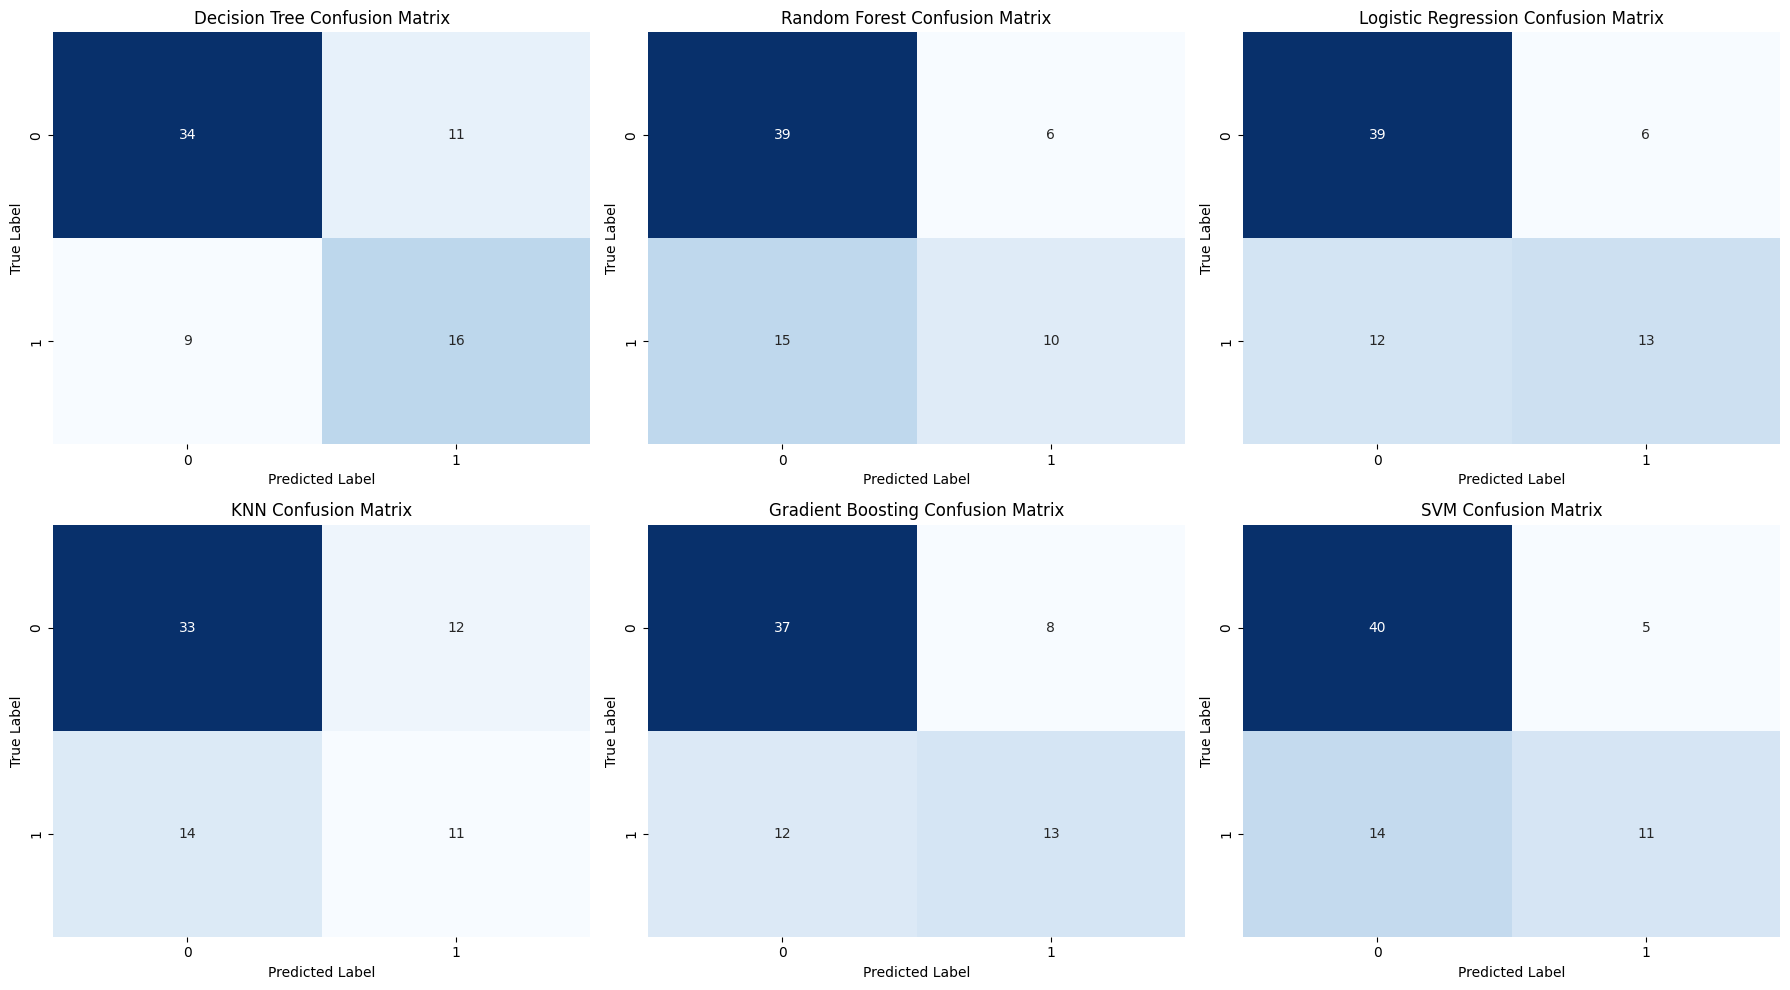

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, (name, preds) in enumerate(model_predictions.items()):
    cm = confusion_matrix(y_test_mock, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### 4. Analyze Misclassified Records
Let's extract and view some actual samples that were misclassified by the models (e.g., Random Forest or Gradient Boosting) to perform a deeper error analysis.

In [4]:
# Select a representative model for detailed misclassification review (e.g., Random Forest)
target_model = 'Random Forest'
rf_preds = model_predictions[target_model]

# Identify indices of misclassified instances
misclassified_idx = np.where(rf_preds != y_test_mock)[0]

# Create a DataFrame of misclassified records
misclassified_df = X_test_mock.iloc[misclassified_idx].copy()
misclassified_df['True_Label'] = y_test_mock[misclassified_idx]
misclassified_df['Predicted_Label'] = rf_preds[misclassified_idx]

print(f"Number of misclassified records by {target_model}: {len(misclassified_df)} out of {len(y_test_mock)}")
display(misclassified_df.head(10))

Number of misclassified records by Random Forest: 21 out of 70


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,True_Label,Predicted_Label
170,7,159.0,64.0,29.0,125.0,27.4,0.294,40,0,1
15,1,125.0,50.0,40.0,167.0,33.3,0.962,28,1,0
19,0,140.0,65.0,26.0,130.0,42.6,0.431,24,1,0
96,9,106.0,52.0,29.0,125.0,31.2,0.380,42,0,1
178,6,104.0,74.0,18.0,156.0,29.9,0.722,41,1,0
146,5,85.0,74.0,22.0,125.0,29.0,1.224,32,1,0
30,0,162.0,76.0,56.0,100.0,53.2,0.759,25,1,0
226,0,119.0,72.0,29.0,125.0,32.4,0.141,24,1,0
108,3,80.0,82.0,31.0,70.0,34.2,1.292,27,1,0
198,0,107.0,62.0,30.0,74.0,36.6,0.757,25,1,0
